### 1. Импорты и настройки:

In [1]:
# импорт библиотек

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns  #надстройка matplotlib
from numba.np.math.numbers import NAN

In [2]:
# отключаем предупреждения
import warnings

warnings.filterwarnings('ignore')

сразу юзаю Автоматизацию EDA с ydata-profiling, чтобы при необходимости можно было попробовать использовать на этом учебном проекте

In [3]:
# Автоматический EDA
# Здесь пришлось повозиться с переустановкой пакетов setuptools

from ydata_profiling import ProfileReport

### Задание:
- Проведите оценку данных по столбцам, посмотрите визуально на распределение данных, определите базовые статистики, где это возможно.
- Найдите выбросы в данных, для наглядности используйте соответствующие типы визуализаций. Попробуйте объяснить их появление в наборе.

- Задайте 4-6 вопросов к вашим данным и постарайтесь ответить на них графически (один вопрос/гипотеза — один график).

Вы можете использовать любую библиотеку для визуализации данных. Гайд по применению основных методов построения графиков из библиотеки matplotlib можно найти по ссылке.

- Желательно, но не обязательно:
Если данные содержат пропуски, заполните их и обоснуйте своё решение. Проверьте, как изменились базовые статистики до и после замены.
Требования по оформлению графиков:

- У графиков должен быть заголовок, подписи осей, легенда (опционально). Каждая визуализация должным образом оформлена и может быть интерпретирована даже в отрыве от контекста.

#### Важно!

Оставляйте свои комментарии к графикам: отвечает ли визуализация на поставленный вопрос, что вы наблюдаете в данных, какие выводы можно сделать и т.д. Ход ваших мыслей так же важен, как и написанный вами код.

### 2. Загрузка Данных:

In [4]:
sal = pd.read_csv('https://raw.githubusercontent.com/catprokhorova/HW_datasets/main/EDA_1/salary_dataset.csv', index_col=0)
# index_col=0 Удаление нумерации строк, чтобы не дублировалась в пандас
sal

,Age,Gender,Education Level,Job Title,Years of Experience,Salary,Country,Race
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0,UK,White
1,28.0,Female,Master's,Data Analyst,3.0,65000.0,USA,Hispanic
2,45.0,Male,PhD,Senior Manager,15.0,150000.0,Canada,White
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0,USA,Hispanic
4,52.0,Male,Master's,Director,20.0,200000.0,USA,Asian
...,...,...,...,...,...,...,...,...
6699,49.0,Female,PhD,Director of Marketing,20.0,200000.0,UK,Mixed
6700,32.0,Male,High School,Sales Associate,3.0,50000.0,Australia,Australian
6701,30.0,Female,Bachelor's Degree,Financial Manager,4.0,55000.0,China,Chinese
6702,46.0,Male,Master's Degree,Marketing Manager,14.0,140000.0,China,Korean



 ### 📋 Описание столбцов датасета

| Столбец | Тип | Описание |
|---------|---|----------|
| **Age** | float64 | Возраст: Возраст участников набора данных, выраженный в годах. |
| **Gender** | object | Пол: Половая идентичность участников, указывающая на их пол или гендерную идентичность. |
| **Education** | object  | Уровень образования: Высший уровень образования, достигнутый участниками, указывающий на их квалификацию или степень. |
| **Job** | object  | Должность: Род занятий или должность участников, указывающая на их профессиональную роль или положение. |
| **Years** | float64 | Опыт работы: Количество лет профессионального опыта, накопленного участниками в соответствующей области. |
| **Salary** | float64 | Заработная плата: Уровень дохода или заработная плата, получаемая участниками, указывающая на их денежное вознаграждение. |
| **Country** | object | Страна: Страна проживания или происхождения участников, предоставляющая географическую информацию. |
| **Race** | object | Раса: Расовая принадлежность или этническая принадлежность участников, отражающая их конкретную расовую или этническую группу. |

#### 2.1. Первичный осмотр данных:

In [5]:
sal.sample(10, random_state=33)

,Age,Gender,Education Level,Job Title,Years of Experience,Salary,Country,Race
3537,34.0,Male,Bachelor's Degree,Junior Web Developer,3.0,50000.0,USA,Asian
221,31.0,Female,Bachelor's,Junior Social Media Specialist,3.0,45000.0,UK,Welsh
4835,27.0,Female,Bachelor's Degree,Junior Software Engineer,2.0,48000.0,UK,White
6158,40.0,Female,Bachelor's Degree,Financial Manager,16.0,215000.0,USA,Hispanic
1574,40.0,Male,PhD,Senior Software Engineer,12.0,160000.0,China,Chinese
2332,30.0,Female,Bachelor's Degree,Software Engineer,5.0,90000.0,China,Korean
2358,32.0,Male,Master's Degree,Product Manager,7.0,110000.0,UK,Welsh
4163,34.0,Female,Bachelor's Degree,Human Resources Manager,9.0,99000.0,UK,Welsh
6096,36.0,Female,PhD,Research Scientist,13.0,185000.0,China,Chinese
522,26.0,Male,Bachelor's,Data Analyst,3.0,130000.0,Canada,Black


In [6]:
sal.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary,Country,Race
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0,UK,White
1,28.0,Female,Master's,Data Analyst,3.0,65000.0,USA,Hispanic
2,45.0,Male,PhD,Senior Manager,15.0,150000.0,Canada,White
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0,USA,Hispanic
4,52.0,Male,Master's,Director,20.0,200000.0,USA,Asian


In [7]:
sal.tail()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary,Country,Race
6699,49.0,Female,PhD,Director of Marketing,20.0,200000.0,UK,Mixed
6700,32.0,Male,High School,Sales Associate,3.0,50000.0,Australia,Australian
6701,30.0,Female,Bachelor's Degree,Financial Manager,4.0,55000.0,China,Chinese
6702,46.0,Male,Master's Degree,Marketing Manager,14.0,140000.0,China,Korean
6703,26.0,Female,High School,Sales Executive,1.0,35000.0,Canada,Black


с виду аномалий нет

#### 2.2. Стат сводка:

In [8]:
sal.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,6702.0,33.620859,7.614633,21.0,28.0,32.0,38.0,62.0
Years of Experience,6701.0,8.094687,6.059003,0.0,3.0,7.0,12.0,34.0
Salary,6699.0,115326.964771,52786.183911,350.0,70000.0,115000.0,160000.0,250000.0


Здесь нужно обратить внимание на Salary, минимальная зарплата у нас 350!, при Q1 = 70000 это странно проверить!

- Возможно ли, что сотрудники с самой низкой зарплатой это либо кто-то на частичной ставке или испытательном сроке, либо это аномалия выбивающаяся выбросом в данных по зарплате??

In [9]:
sal.describe(include=['object', 'category']).T

,count,unique,top,freq
Gender,6702,3,Male,3674
Education Level,6701,7,Bachelor's Degree,2267
Job Title,6702,193,Software Engineer,518
Country,6704,5,USA,1360
Race,6704,10,White,1968


- три уникальных гендера!!!
- 193 уникальных значений должностей странно, скорее всего это дубликация, проверить!

### 3. Качество данных:

#### 3.1. Проверим датафрейм .info() и проверим наличие пропусков:

In [10]:
sal.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6704 entries, 0 to 6703
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  6702 non-null   float64
 1   Gender               6702 non-null   object 
 2   Education Level      6701 non-null   object 
 3   Job Title            6702 non-null   object 
 4   Years of Experience  6701 non-null   float64
 5   Salary               6699 non-null   float64
 6   Country              6704 non-null   object 
 7   Race                 6704 non-null   object 
dtypes: float64(3), object(5)
memory usage: 471.4+ KB


#### 3.2.(часть 1) Анализ пропусков:

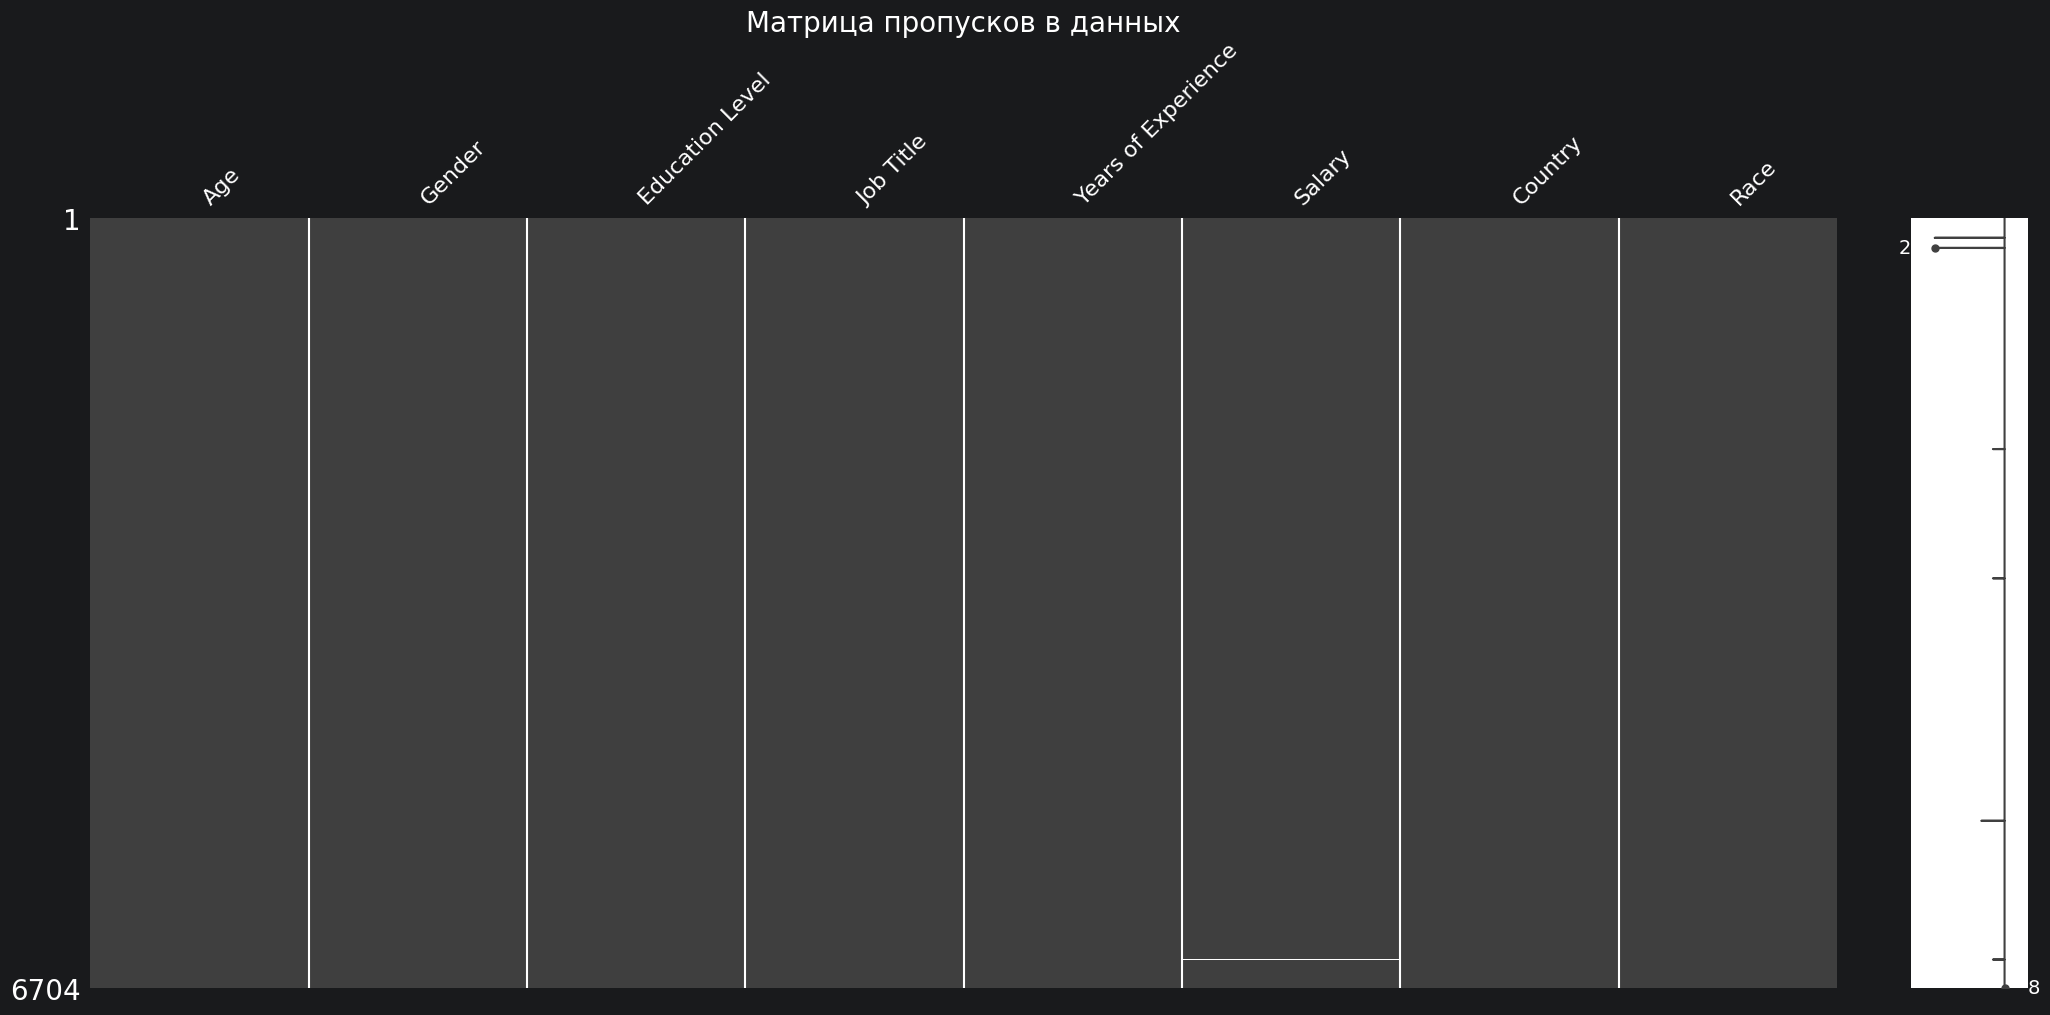

In [11]:
import missingno as msno

# Матрица missingno — это визуализация нашего DataFrame, где белые полосы — это пропуски.
# Она помогает мгновенно увидеть, в каких столбцах есть проблемы.
msno.matrix(sal)
plt.title('Матрица пропусков в данных', fontsize=20)
plt.show()

В матрице пропусков заметны пропуски только в 'Salary', но у нас также есть пропуски в других колонках

In [12]:
sal.isnull().sum()

Age                    2
Gender                 2
Education Level        3
Job Title              2
Years of Experience    3
Salary                 5
Country                0
Race                   0
dtype: int64

- У нас есть небольшое количество пропусков в данных. Т.К. их небольшое количество можно взгялнуть на эти пропуски по отдельным колонкам и посмотреть

In [13]:
sal[sal['Salary'].isnull()] # методом просмотра каждой колонки нашел 172, 260, 2011, 3136, 5247, 6455. по колонкам просмотрел пропуски

,Age,Gender,Education Level,Job Title,Years of Experience,Salary,Country,Race
172,NaN,NaN,NaN,NaN,NaN,NaN,UK,White
260,NaN,NaN,NaN,NaN,NaN,NaN,Canada,White
3136,31.0,Male,Master's Degree,Full Stack Engineer,8.0,NaN,Canada,White
5247,26.0,Female,Bachelor's Degree,Social M,NaN,NaN,USA,White
6455,36.0,Male,Bachelor's Degree,Sales Director,6.0,NaN,Canada,White


In [14]:
# составляю список индексов строк, и помещаю в список, чтобы вывести отдельной таблицей
row_missed = [172, 260, 2011, 3136, 5247, 6455] # список индексов строк с пропусками
df_row_missed = sal.iloc[row_missed]
df_row_missed

,Age,Gender,Education Level,Job Title,Years of Experience,Salary,Country,Race
172,NaN,NaN,NaN,NaN,NaN,NaN,UK,White
260,NaN,NaN,NaN,NaN,NaN,NaN,Canada,White
2011,27.0,Male,NaN,Developer,7.0,100000.0,UK,White
3136,31.0,Male,Master's Degree,Full Stack Engineer,8.0,NaN,Canada,White
5247,26.0,Female,Bachelor's Degree,Social M,NaN,NaN,USA,White
6455,36.0,Male,Bachelor's Degree,Sales Director,6.0,NaN,Canada,White


In [15]:
# Удаляем пропуски строк 172 и 260:
# сперва создадим новую версию датасета, чтобы не затереть исходник для сравнения
sal_clean = sal.copy()

sal_clean = sal_clean.dropna(thresh=3) # минимум 3 заполненные колонки в строке, для сохранения в датасете
sal_clean

,Age,Gender,Education Level,Job Title,Years of Experience,Salary,Country,Race
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0,UK,White
1,28.0,Female,Master's,Data Analyst,3.0,65000.0,USA,Hispanic
2,45.0,Male,PhD,Senior Manager,15.0,150000.0,Canada,White
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0,USA,Hispanic
4,52.0,Male,Master's,Director,20.0,200000.0,USA,Asian
...,...,...,...,...,...,...,...,...
6699,49.0,Female,PhD,Director of Marketing,20.0,200000.0,UK,Mixed
6700,32.0,Male,High School,Sales Associate,3.0,50000.0,Australia,Australian
6701,30.0,Female,Bachelor's Degree,Financial Manager,4.0,55000.0,China,Chinese
6702,46.0,Male,Master's Degree,Marketing Manager,14.0,140000.0,China,Korean


In [16]:
print(sal_clean.loc[[3136, 5247, 6455]]) # проверяем пропуски по ЗП 2 строки

       Age  Gender    Education Level            Job Title  \
3136  31.0    Male    Master's Degree  Full Stack Engineer   
5247  26.0  Female  Bachelor's Degree             Social M   
6455  36.0    Male  Bachelor's Degree       Sales Director   

      Years of Experience  Salary Country   Race  
3136                  8.0     NaN  Canada  White  
5247                  NaN     NaN     USA  White  
6455                  6.0     NaN  Canada  White  


In [17]:
# 1. Выделяем список должностей для строк 3136 и 6455
target_jobs = sal_clean.loc[[3136, 5247, 6455], 'Job Title'].unique()
# 2. Фильтруем наш датасет только по этим должностям и считаем медиану, среднее, моду
sal_clean[sal_clean['Job Title'].isin(target_jobs)].groupby('Job Title')['Salary'].agg([
    ('Количество', 'count'),
    ('Среднее', 'mean'),
    ('Медиана', 'median'),
    ('Мода', lambda x: x.mode().iloc[0] if not x.mode().empty else None)
]
)

,Количество,Среднее,Медиана,Мода
Job Title,,,,
Full Stack Engineer,308,126719.840909,120869.0,115000.0
Sales Director,62,124112.903226,140000.0,140000.0
Social M,0,NaN,NaN,NaN


На этом шаге я обнаружил, что мы не можем найти данные для замены пропусков у сотрудника с индексом 5247. Поэтому сперва буду работать с дубликацией, а затем уже вернемся к обработке пропусков!!!

В дальнейшем взять за основу порядок действий:
- Сперва искать дубликаты и аномалии в текстовых формулировках;
- ПОТОМ УЖЕ ИСЧЕМ ПРОПУСКИ И ВЫБРОСЫ И ПРОЧЕЕ!!!

#### Перечень выявленных недостатки по данным, на этапах анализа пропусков и анализа дубликатов будут занесены ниже:
1. смотри строки с номерами 172 и 260. они удалятся там ничего нет, а гадать пальцем в небо, когда у нас (устранено);

2. 2011 здесь пропуск в образовании, возможно это случайный пропуск, или же (если учесть что некоторые люди приходят в разработку без образования, то возможно так и есть) поэтому нужно подумать, оставить этот пропуск, или есть какая-то категория, кто без образования и записать пропуск такими данными (устранено);

3. 3136 и 6455 если это какая-то корпоративная таблица, тогда это случайный пропуск, организация не может не знать или скрывать зарплату своих работников. Здесь будем искать замену из таких же должностей (устранено).

4. У нас также ранее обнаружена аномально низкая зарплата 350! проверить (Устранено);

5. три гендера. Т.к. в описании графы 'Gender' у нас указано: "Половая идентичность участников, указывающая на их пол \или гендерную идентичность./ пишем на региональные особенности (пропущено);

6. row 5247 - job title 'Social M' проверить, скорее всего это недописанная должность! также разночтение в наименовании должностей (устранено);

7. Проверка дубликатов показала, что у нас 1535 дублей (устранено);

8. разное написание уровней образования, (проверка показала, что у нас есть одинаковые уровни, но разное написание, нужно преобразовать, чтобы не было разночтений в один формат, возможно преобразовать в тип данных каталог (устранено);


#### 3.3. Анализ дубликатов:

In [18]:
# Передаем список колонок, которые должны совпадать
sal_clean[sal_clean.duplicated(subset=['Age', 'Gender', 'Education Level', 'Job Title', 'Years of Experience', 'Salary', 'Country', 'Race'])]


,Age,Gender,Education Level,Job Title,Years of Experience,Salary,Country,Race
253,28.0,Male,Bachelor's,Junior Business Development Associate,2.0,40000.0,USA,Asian
310,29.0,Female,Bachelor's,Junior Business Development Associate,1.5,35000.0,Australia,White
345,33.0,Male,Bachelor's,Junior Business Analyst,4.0,60000.0,Canada,Black
374,44.0,Female,PhD,Senior Business Analyst,15.0,150000.0,UK,White
392,31.0,Female,Bachelor's,Software Engineer,6.0,155000.0,UK,Welsh
...,...,...,...,...,...,...,...,...
6683,51.0,Female,Master's Degree,Content Marketing Manager,19.0,190000.0,UK,White
6684,37.0,Male,Bachelor's Degree,Sales Director,7.0,90000.0,China,Chinese
6692,24.0,Male,Bachelor's Degree,Sales Executive,1.0,35000.0,Canada,Asian
6697,51.0,Female,Master's Degree,Senior Product Marketing Manager,19.0,190000.0,UK,White


In [19]:
# У нас выявлено 1535 дубликатов
# Проверка точечных дубликатов: ищем клон строки 253
sal_clean[
    (sal_clean['Age'] == 28.0) &
    (sal_clean['Gender'] == 'Male') &
    (sal_clean['Job Title'] == 'Junior Business Development Associate')
]

,Age,Gender,Education Level,Job Title,Years of Experience,Salary,Country,Race
212,28.0,Male,Bachelor's,Junior Business Development Associate,2.0,40000.0,USA,Asian
253,28.0,Male,Bachelor's,Junior Business Development Associate,2.0,40000.0,USA,Asian


клон строки найден, удаляем полные дубликаты. Ранее мы убрали индексы из базового датафрейма при чтении, это поможет нам найти полные дубликаты, тк индекс строк был бы разным - дублик

In [20]:
# удаляем дубликаты:
# sal_clean = sal_clean.drop_duplicates()
# ИЛИ
sal_clean.drop_duplicates(inplace=True)
sal_clean
print(f' Удалено полных дубликатов: {len(sal) - len(sal_clean):,}')
print(f'Размер после очистки: {len(sal_clean):,} строк')

 Удалено полных дубликатов: 1,537
Размер после очистки: 5,167 строк


In [21]:
# проверим уникальные названия колонки 'Education Level':
sal_clean['Education Level'].unique()

#здесь мы увидели что у нас есть дублирующиеся названия. мы можем привести все названия без повторов.
#также можно попробовать провести оптимизацию, и преобразовать objects типы в каталоги. как на лекциях


array(["Bachelor's", "Master's", 'PhD', "Bachelor's Degree",
       "Master's Degree", nan, 'High School', 'phD'], dtype=object)

In [22]:
# создаем словарь наименований 'Education Level':
education_mapping = {
    "Bachelor's Degree": "Bachelor's",
    "Master's Degree": "Master's",
    'phD': 'PhD'
}

# проводим замену в колонке:
sal_clean['Education Level'] = sal_clean['Education Level'].replace(education_mapping)

print(sal_clean['Education Level'].unique())
# ["Bachelor's" "Master's" 'PhD' nan 'High School']

["Bachelor's" "Master's" 'PhD' nan 'High School']


In [23]:
sal_clean['Job Title'] = sal_clean['Job Title'].str.lower().str.strip()
sal_clean

,Age,Gender,Education Level,Job Title,Years of Experience,Salary,Country,Race
0,32.0,Male,Bachelor's,software engineer,5.0,90000.0,UK,White
1,28.0,Female,Master's,data analyst,3.0,65000.0,USA,Hispanic
2,45.0,Male,PhD,senior manager,15.0,150000.0,Canada,White
3,36.0,Female,Bachelor's,sales associate,7.0,60000.0,USA,Hispanic
4,52.0,Male,Master's,director,20.0,200000.0,USA,Asian
...,...,...,...,...,...,...,...,...
6698,37.0,Male,Bachelor's,junior sales representative,6.0,75000.0,Canada,Asian
6699,49.0,Female,PhD,director of marketing,20.0,200000.0,UK,Mixed
6700,32.0,Male,High School,sales associate,3.0,50000.0,Australia,Australian
6701,30.0,Female,Bachelor's,financial manager,4.0,55000.0,China,Chinese


In [24]:
print(f"Осталось уникальных должностей: {sal_clean['Job Title'].nunique()}")
sorted(sal_clean['Job Title'].unique())

Осталось уникальных должностей: 192


['account manager',
 'accountant',
 'administrative assistant',
 'back end developer',
 'business analyst',
 'business development manager',
 'business intelligence analyst',
 'ceo',
 'chief data officer',
 'chief technology officer',
 'content marketing manager',
 'copywriter',
 'creative director',
 'customer service manager',
 'customer service rep',
 'customer service representative',
 'customer success manager',
 'customer success rep',
 'data analyst',
 'data entry clerk',
 'data scientist',
 'delivery driver',
 'developer',
 'digital content producer',
 'digital marketing manager',
 'digital marketing specialist',
 'director',
 'director of business development',
 'director of data science',
 'director of engineering',
 'director of finance',
 'director of hr',
 'director of human capital',
 'director of human resources',
 'director of marketing',
 'director of operations',
 'director of product management',
 'director of sales',
 'director of sales and marketing',
 'event coord

тут хотел заавтоматизировать, как искать похожие совпадения по должностям, но ИИ-шка выдала не совсем точную автоматизацию в итоге другой метод перебора по первому слову вакансии буду использовать

In [25]:
from difflib import SequenceMatcher

unique_jobs = sal_clean['Job Title'].unique()
duplicates_found = []

# Сравниваем каждую должность с каждой
for i in range(len(unique_jobs)):
    for j in range(i + 1, len(len(unique_jobs)) if hasattr(unique_jobs, 'len') else len(unique_jobs)):
        job1 = unique_jobs[i]
        job2 = unique_jobs[j]

        # Считаем коэффициент схожести (например, выше 0.6 — это очень похожие строки)
        ratio = SequenceMatcher(None, job1, job2).ratio()

        # Отсекаем совсем разные, берем только те, что похожи, но не одинаковы
        if 0.65 < ratio < 1.0:
            duplicates_found.append((job1, job2, round(ratio, 2)))

# Сортируем по степени похожести и выводим
duplicates_found.sort(key=lambda x: x[2], reverse=True)
for job1, job2, score in duplicates_found[:30]: # выведем топ-30 самых подозрительных
    print(f"Похожи на {int(score*100)}%: '{job1}' <---> '{job2}'")

Похожи на 98%: 'junior hr generalist' <---> 'juniour hr generalist'
Похожи на 98%: 'junior hr coordinator' <---> 'juniour hr coordinator'
Похожи на 94%: 'senior project manager' <---> 'senior it project manager'
Похожи на 93%: 'junior sales representative' <---> 'senior sales representative'
Похожи на 93%: 'junior marketing specialist' <---> 'senior marketing specialist'
Похожи на 93%: 'senior marketing coordinator' <---> 'junior marketing coordinator'
Похожи на 93%: 'junior operations coordinator' <---> 'senior operations coordinator'
Похожи на 92%: 'senior consultant' <---> 'senior it consultant'
Похожи на 92%: 'senior financial analyst' <---> 'junior financial analyst'
Похожи на 92%: 'senior software engineer' <---> 'junior software engineer'
Похожи на 92%: 'senior marketing manager' <---> 'junior marketing manager'
Похожи на 92%: 'junior software developer' <---> 'senior software developer'
Похожи на 92%: 'senior marketing analyst' <---> 'junior marketing analyst'
Похожи на 92%: 'j

Ищем должности по группировке по первому слову вакансии

In [26]:
# Получаем уникальные должности
unique_jobs = pd.Series(sal_clean['Job Title'].unique())

# Группируем должности по их первому слову
first_words = unique_jobs.str.split().str[0]

# Выводим группы, где нашлось больше одной должности с одинаковым первым словом
for word, group in unique_jobs.groupby(first_words):
    if len(group) > 1:
        print(f"📌 Начинаются на '{word}':")
        print(group.tolist())
        print("-" * 40)

📌 Начинаются на 'business':
['business analyst', 'business intelligence analyst', 'business development manager']
----------------------------------------
📌 Начинаются на 'chief':
['chief technology officer', 'chief data officer']
----------------------------------------
📌 Начинаются на 'customer':
['customer service rep', 'customer success rep', 'customer service manager', 'customer service representative', 'customer success manager']
----------------------------------------
📌 Начинаются на 'data':
['data analyst', 'data entry clerk', 'data scientist']
----------------------------------------
📌 Начинаются на 'digital':
['digital marketing manager', 'digital content producer', 'digital marketing specialist']
----------------------------------------
📌 Начинаются на 'director':
['director', 'director of marketing', 'director of operations', 'director of sales', 'director of human resources', 'director of product management', 'director of finance', 'director of sales and marketing', 'dire

In [27]:
job_mapping = {
    # Чистим опечатки в слове juniour
    'juniour hr generalist': 'junior hr generalist',
    'juniour hr coordinator': 'junior hr coordinator',

    # Объединяем директоров HR
    'director of hr': 'director of human resources',
    'human resources director': 'director of human resources',
    'director of human capital': 'director of human resources',

    # Склеиваем HR-менеджеров
    'senior human resources manager': 'senior hr manager',
    'human resources manager': 'hr manager',
    'human resources coordinator': 'hr coordinator',

    # Спасаем нашего Social M и чистим опечатки
    'social m': 'social media manager',
    'social media man': 'social media manager',

    # Сокращения в Customer Service
    'customer service rep': 'customer service representative',
    'customer success rep': 'customer success manager' # или representative, если логичнее
}

# Применяем массовую замену
sal_clean['Job Title'] = sal_clean['Job Title'].replace(job_mapping)

# Смотрим на финальный результат
print(f"Итого уникальных должностей после глобальной чистки: {sal_clean['Job Title'].nunique()}")

Итого уникальных должностей после глобальной чистки: 181


In [28]:
# Возвращаем капитализацию символов в должности
sal_clean['Job Title'] = sal_clean['Job Title'].str.capitalize()
sal_clean.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary,Country,Race
0,32.0,Male,Bachelor's,Software engineer,5.0,90000.0,UK,White
1,28.0,Female,Master's,Data analyst,3.0,65000.0,USA,Hispanic
2,45.0,Male,PhD,Senior manager,15.0,150000.0,Canada,White
3,36.0,Female,Bachelor's,Sales associate,7.0,60000.0,USA,Hispanic
4,52.0,Male,Master's,Director,20.0,200000.0,USA,Asian


#### 3.2.(часть 2) Анализ пропусков:
Продолжаем анализ пропусков

In [29]:
sal_clean.isnull().sum()

Age                    0
Gender                 0
Education Level        1
Job Title              0
Years of Experience    1
Salary                 3
Country                0
Race                   0
dtype: int64

In [30]:
sal_clean[sal_clean['Salary'].isnull()] # методом просмотра каждой колонки нашел 172, 260, 2011, 3136, 5247, 6455. по колонкам просмотрел пропуски

,Age,Gender,Education Level,Job Title,Years of Experience,Salary,Country,Race
3136,31.0,Male,Master's,Full stack engineer,8.0,NaN,Canada,White
5247,26.0,Female,Bachelor's,Social media manager,NaN,NaN,USA,White
6455,36.0,Male,Bachelor's,Sales director,6.0,NaN,Canada,White


In [31]:
# 1. Шаг: Вытаскиваем уникальные названия должностей, у которых зарплата пропущена
jobs_with_nan = sal_clean[sal_clean['Salary'].isnull()]['Job Title'].unique()

# 2. Шаг: Фильтруем основной датафрейм — оставляем только эти должности,
# группируем и считаем показатели по ИХ РЕАЛЬНЫМ (не пустующим) зарплатам
nan_jobs_stats = sal_clean[sal_clean['Job Title'].isin(jobs_with_nan)].groupby('Job Title')['Salary'].agg([
    ('Количество заполненных', 'count'),
    ('Среднее', 'mean'),
    ('Медиана', 'median'),
    ('Мода', lambda x: x.mode().iloc[0] if not x.mode().empty else None)
])

# Выводим результат
nan_jobs_stats

,Количество заполненных,Среднее,Медиана,Мода
Job Title,,,,
Full stack engineer,263,127272.855513,123781.0,115000.0
Sales director,40,116875.000000,140000.0,75000.0
Social media manager,11,59090.909091,55000.0,55000.0


In [32]:
sal_clean['Salary'] = sal_clean['Salary'].fillna(
    sal_clean.groupby('Job Title')['Salary'].transform('median')
)

In [33]:
sal_clean.loc[5247]

Age                                    26.0
Gender                               Female
Education Level                  Bachelor's
Job Title              Social media manager
Years of Experience                     NaN
Salary                              55000.0
Country                                 USA
Race                                  White
Name: 5247, dtype: object

In [34]:
# Заполняем пропуски в опыте медианой по должности
sal_clean['Years of Experience'] = sal_clean['Years of Experience'].fillna(
    sal_clean.groupby('Job Title')['Years of Experience'].transform('median')
)

In [35]:
sal_clean[sal_clean['Education Level'].isnull()]

,Age,Gender,Education Level,Job Title,Years of Experience,Salary,Country,Race
2011,27.0,Male,NaN,Developer,7.0,100000.0,UK,White


In [36]:
# 1. Фильтруем всех, у кого в должности есть 'developer'
dev_filter = sal_clean['Job Title'].str.contains('developer', case=False, na=False)

# 2. Считаем моду (самое частое образование) среди них
dev_education_mode = sal_clean[dev_filter]['Education Level'].mode()[0]
print(f"📊 Самое частая степень среди разработчиков: {dev_education_mode}")

# 3. Автоматически заменяем пропуск у строки 2011 на эту моду
sal_clean.loc[2011, 'Education Level'] = dev_education_mode

# 4. Проверяем, что у сотрудника 2011 теперь стоит эта степень
print("\n=== Проверка строки 2011 ===")
print(sal_clean.loc[[2011], ['Job Title', 'Education Level', 'Salary']])

# 5. Финальная проверка: сколько ВСЕГО пропусков осталось в этой колонке?
print(f"\nОсталось пропусков в Education Level: {sal_clean['Education Level'].isnull().sum()}")

📊 Самое частая степень среди разработчиков: Bachelor's

=== Проверка строки 2011 ===
      Job Title Education Level    Salary
2011  Developer      Bachelor's  100000.0

Осталось пропусков в Education Level: 0


У нашего разработчика имеется пропуск в колонке 'Education Level' с учетом того, что у разработчика большой опыт 7 лет, и зарплата на уровне медианной для всех разработчиков, а самый многочисленный уровень образования у разработчиков это Бакалаврская степень.
Заполню замену пропуска на Bachelor's.
таким образом мы избавимся от пропусков

In [37]:
# еще раз сверяем количество пропусков по датасету
sal_clean.isnull().sum()

Age                    0
Gender                 0
Education Level        0
Job Title              0
Years of Experience    0
Salary                 0
Country                0
Race                   0
dtype: int64

Т.к. мы производили замену разноитающихся названий и преобразовывали все под одну форму, нужно проверить на дубликацию еще раз

In [38]:
# Передаем список колонок, которые должны совпадать
sal_clean[sal_clean.duplicated(subset=['Age', 'Gender', 'Education Level', 'Job Title', 'Years of Experience', 'Salary', 'Country', 'Race'])]


,Age,Gender,Education Level,Job Title,Years of Experience,Salary,Country,Race
4529,31.0,Female,Bachelor's,Junior hr coordinator,4.0,50000.0,China,Korean


In [39]:
# У нас выявлено 1535 дубликатов
# Проверка точечных дубликатов: ищем клон строки 253
sal_clean[
    (sal_clean['Age'] == 31.0) &
    (sal_clean['Gender'] == 'Female') &
    (sal_clean['Job Title'] == 'Junior hr coordinator') &
    (sal_clean['Years of Experience'] == 4) &
    (sal_clean['Education Level'] == "Bachelor's") &
    (sal_clean['Country'] == 'China')
]

,Age,Gender,Education Level,Job Title,Years of Experience,Salary,Country,Race
168,31.0,Female,Bachelor's,Junior hr coordinator,4.0,50000.0,China,Korean
4529,31.0,Female,Bachelor's,Junior hr coordinator,4.0,50000.0,China,Korean


In [40]:
sal_clean.drop_duplicates(inplace=True)
sal_clean
print(f' Удалено полных дубликатов: {len(sal) - len(sal_clean):,}')
print(f'Размер после очистки: {len(sal_clean):,} строк')

 Удалено полных дубликатов: 1,538
Размер после очистки: 5,166 строк


#### 3.4. Работаем с выбросами в данных:

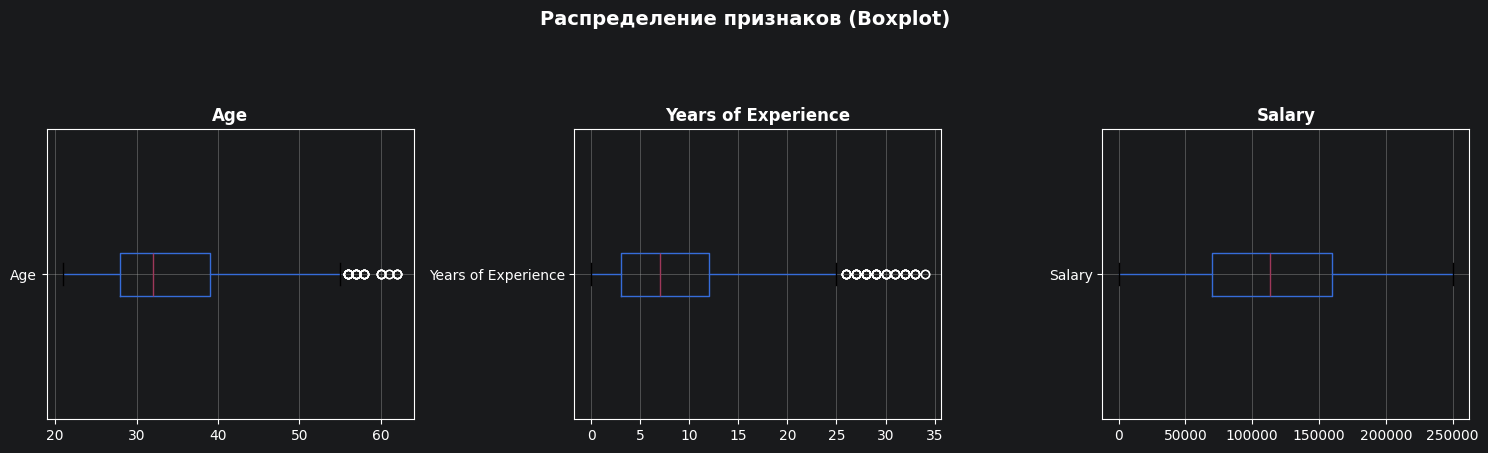

In [41]:
# числовые характеристики работников для анализа выбросов:
emissions_testing = ['Age', 'Years of Experience', 'Salary']

# Boxplot для всех audio features
# Меняем на 1 строку и 3 столбца
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, col in enumerate(emissions_testing):
    ax = axes[idx]  # Теперь здесь всё отработает идеально
    sal_clean.boxplot(column=col, ax=ax, vert=False)
    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.set_xlabel('')

plt.suptitle('Распределение признаков (Boxplot)', fontsize=14, fontweight='bold', y=1.12)
plt.tight_layout()
plt.show()

Ранее я фиксировал, в основных статистических показателях, что у нас min значение по зарплате было 350. График же показывает, что выбросы по зарплате отсутствуют. посмотрим на топ 5 или топ 10 сотрудников с самой низкой , вдруг их стаж покажет, что это прям новички или есть какая-то причина

In [42]:
# Сортируем по колонке Salary от меньшего к большему и берем первые 5 строк
low_salary_top5 = sal_clean.sort_values(by='Salary', ascending=True).head(10)

# Выводим на экран только самые интересные колонки, чтобы не раздувать таблицу
print(low_salary_top5[['Job Title', 'Age', 'Years of Experience', 'Country', 'Salary']])

                               Job Title   Age  Years of Experience  \
259   Junior business operations analyst  29.0                  1.5   
4633               Junior hr coordinator  31.0                  4.0   
1890                 Front end developer  25.0                  1.0   
2654           Software engineer manager  23.0                  1.0   
5031         Junior sales representative  21.0                  0.0   
5165                        Receptionist  22.0                  0.0   
4988         Junior sales representative  21.0                  0.0   
5285                     Sales associate  25.0                  0.0   
5313                     Sales associate  25.0                  0.0   
4975         Junior sales representative  21.0                  0.0   

        Country   Salary  
259         USA    350.0  
4633        USA    500.0  
1890         UK    550.0  
2654         UK    579.0  
5031         UK  25000.0  
5165         UK  25000.0  
4988      China  25000.0  
52

вот и оно у нас минимальные зарплаты сотрудников без опыта на разных должностях получают минимум 25 тыс. а никак не менее 1 тыс. К тому же сотрудник с опытов в 4 года не может получать такую зарплату.
- Поэтому предположение, о том что это выбросы считаю оправданным!

In [43]:
# Удаляем строки, где зарплата нереально маленькая (например, меньше 5000)
sal_clean = sal_clean[sal_clean['Salary'] > 1000]

print(f'Размер после очистки: {len(sal_clean):,} строк')
# мы удалили 4 строки с аномально низкими зарплатами

Размер после очистки: 5,162 строк


рассмотрим возраст
Выведены 3 графика Boxplot. На графиках 'Age' и 'Years of Experience' видны выбросы. НО это более опытные сотрудники, которые работают в индустрии достаточно долго, ко всему прочему скорее всего это высококвалифицированные кадры или руководство. Я думаю, таких сотрудников не нужно удалят как из датасета. нужно посмотреть детальнее

In [44]:
# Фильтруем строки строго по двум интересующим нас должностям
target_jobs = sal_clean['Job Title'].isin(['Software engineer manager', 'Full stack engineer'])

# Выводим уникальные возраста для этих должностей (или можно посмотреть всю таблицу)
print(sal_clean[target_jobs][['Job Title', 'Age', 'Years of Experience', 'Salary']].sort_values(by='Age', ascending=False))

                      Job Title   Age  Years of Experience    Salary
1305  Software engineer manager  62.0                 19.0  200000.0
1304  Software engineer manager  62.0                 20.0  200000.0
1258  Software engineer manager  62.0                 19.0  200000.0
1236  Software engineer manager  62.0                 20.0  200000.0
1225  Software engineer manager  62.0                 19.0  200000.0
...                         ...   ...                  ...       ...
2950  Software engineer manager  23.0                  0.0   52612.0
2494  Software engineer manager  23.0                  1.0  119836.0
2975  Software engineer manager  23.0                  0.0   52779.0
3000  Software engineer manager  23.0                  0.0   52779.0
2414  Software engineer manager  23.0                  1.0  119836.0

[576 rows x 4 columns]


"Software Engineering Manager (SEM) — это технический руководитель, который управляет процессами разработки и развитием команды через людей, а не код"
- Если исходить из этого определения должности, то сотрудник на этой должности, как минимум, должен быть с очень большим опытом коммерческой разработки.
А на выводе данных на эту должность претендуют также и молодые люди без опыта, хоть и на меньшую зарплату, что странно либо это какие-то неточности. либо специфика компании может грейды есть, или за выслугу лет в конкретной компании.
 Именно поэтому нельзя однозначно сказать, в чем конкретная проблема без уточнения.

### 4. Оптимизация памяти:

In [45]:
# Замеры памяти
memory_before_sal = sal.memory_usage(deep=True).sum() / 1024**2
memory_before_sal_clean = sal_clean.memory_usage(deep=True).sum() / 1024**2

print(f" Затраты памяти до подготовки данных: {memory_before_sal:.2f} MB")
print(f" Затраты памяти после подготовки, но без оптимизации: {memory_before_sal_clean:.2f} MB")

 Затраты памяти до подготовки данных: 2.07 MB
 Затраты памяти после подготовки, но без оптимизации: 1.58 MB


In [46]:
sal_clean.dtypes.value_counts()

object     5
float64    3
Name: count, dtype: int64

In [47]:
#украдем скрипт из вебинара (>_<)

# Применяем оптимизацию:
sal_optimized = sal_clean.copy()

# числовые типы
# автоматически подбираются
float_cols = sal_clean.select_dtypes(include=['float64']).columns
for col in float_cols:
    if col in sal_optimized.columns:
        sal_optimized[col] = pd.to_numeric(sal_optimized[col], downcast='float')

# Категориальные типы (уникальность < 20%)
# как я понял, если у нас уникальность данных менее 20% то мы можем поменять тип данных для оптимизации
cat_candidates = ['Gender', 'Education Level', 'Job Title', 'Country', 'Race']
for col in cat_candidates:
    if col in sal_optimized.columns:
        unique_ratio = sal_optimized[col].nunique() / len(sal_optimized)
        if unique_ratio < 0.2:
            sal_optimized[col] = sal_optimized[col].astype('category')
            print(f"📦 {col} → category (уникальность: {unique_ratio:.1%})")

# Замер памяти после оптимизации
memory_after = sal_optimized.memory_usage(deep=True).sum() / 1024**2
print(f"\n💾 Память после: {memory_after:.2f} MB")
print(f"📉 Экономия: {(1 - memory_after/memory_before_sal_clean)*100:.1f}%")

📦 Gender → category (уникальность: 0.1%)
📦 Education Level → category (уникальность: 0.1%)
📦 Job Title → category (уникальность: 3.5%)
📦 Country → category (уникальность: 0.1%)
📦 Race → category (уникальность: 0.2%)

💾 Память после: 0.15 MB
📉 Экономия: 90.7%


In [48]:
# наглядный осмотр изменений
sal_optimized.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5162 entries, 0 to 6702
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   Age                  5162 non-null   float32 
 1   Gender               5162 non-null   category
 2   Education Level      5162 non-null   category
 3   Job Title            5162 non-null   category
 4   Years of Experience  5162 non-null   float32 
 5   Salary               5162 non-null   float32 
 6   Country              5162 non-null   category
 7   Race                 5162 non-null   category
dtypes: category(5), float32(3)
memory usage: 137.5 KB


In [49]:
sal_optimized.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,5162.0,34.012787,7.781670,21.0,28.0,32.0,39.0,62.0
Years of Experience,5162.0,8.356354,6.263064,0.0,3.0,7.0,12.0,34.0
Salary,5162.0,114361.156250,52356.953125,25000.0,70000.0,114290.0,160000.0,250000.0


In [50]:
sal_optimized.describe(include=['category']).T

,count,unique,top,freq
Gender,5162,3,Male,2809
Education Level,5162,4,Bachelor's,2255
Job Title,5162,181,Software engineer,331
Country,5162,5,USA,1078
Race,5162,10,White,1523


### 5. Одномерны анализ:

1. какой портрет наших сотрудников, кто вообще работает в фирме(понятно у нас нет многих внешних характеристик, но есть возраст, пол, стаж, уровень образования)
2. Являются ли люди идентифицирующие себя "по-другому" - меньшинством?

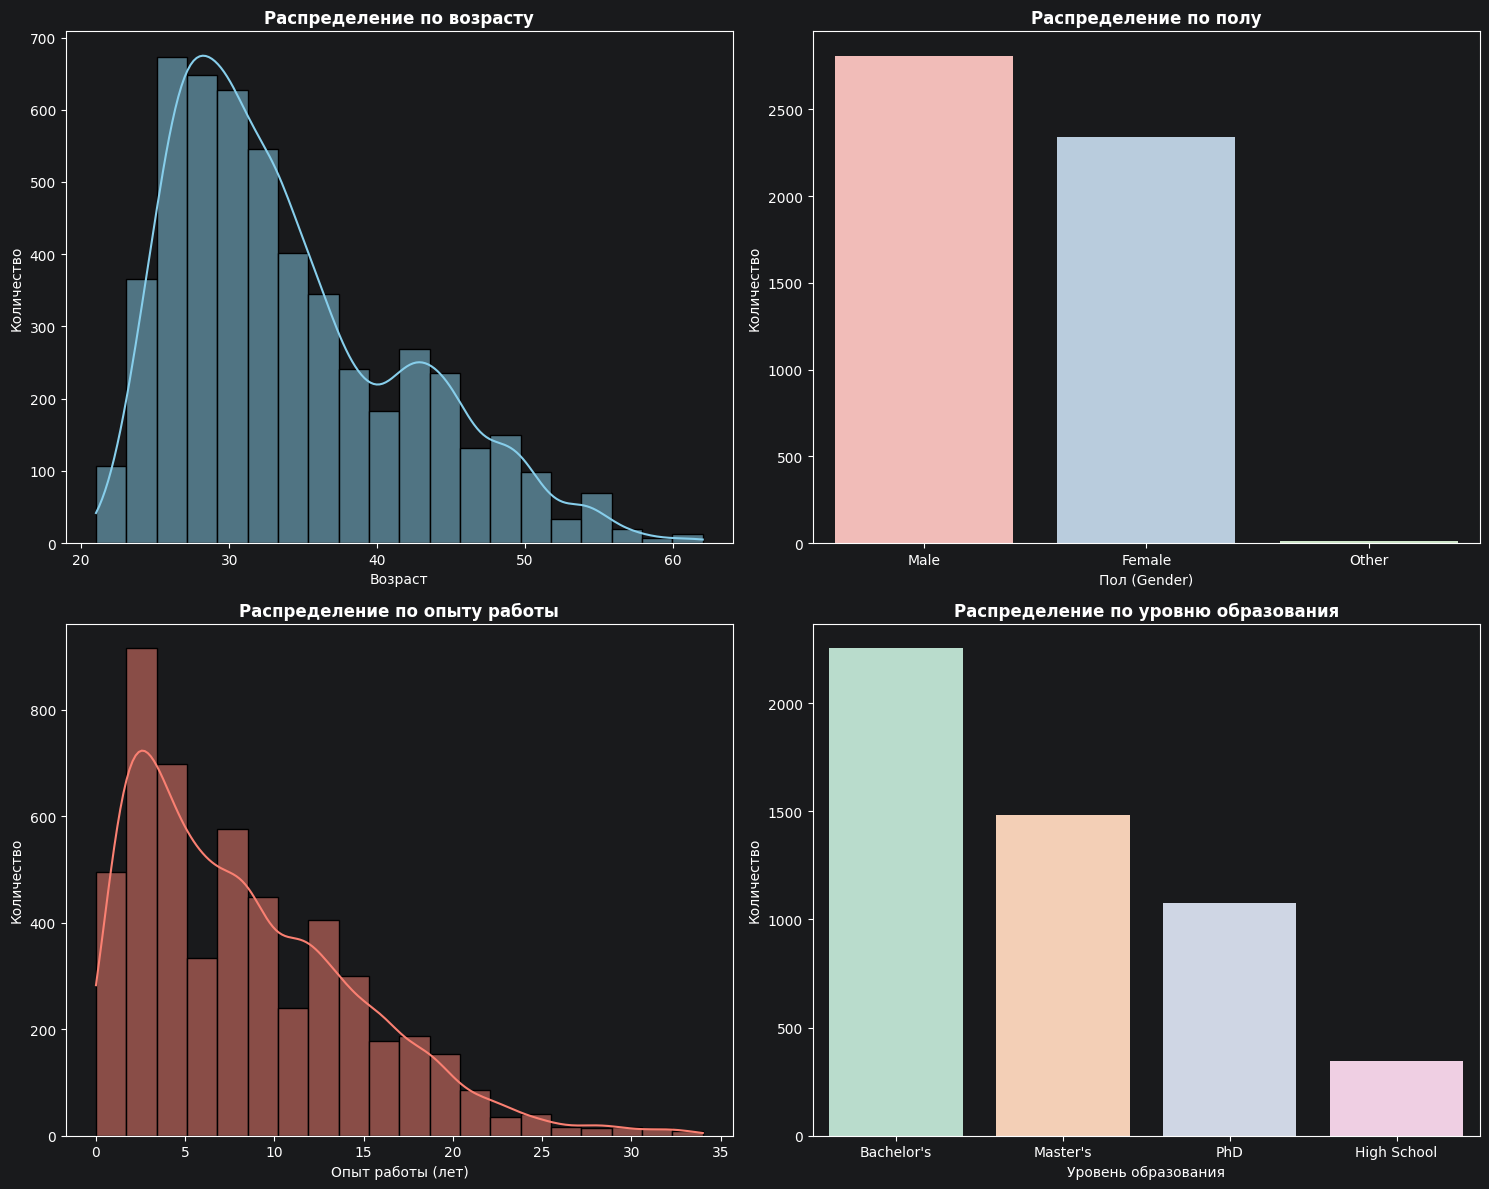

In [51]:
# строим гистограммы:
# Создаем сетку 2x2 для четырех графиков
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Распределение по возрасту (Верхний левый угол)
sns.histplot(data=sal_clean, x='Age', bins=20, kde=True, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Распределение по возрасту', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Возраст')
axes[0, 0].set_ylabel('Количество')

# 2. Распределение по полу (Верхний правый угол)
sns.countplot(data=sal_clean, x='Gender', ax=axes[0, 1], palette='Pastel1')
axes[0, 1].set_title('Распределение по полу', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Пол (Gender)')
axes[0, 1].set_ylabel('Количество')

# 3. Распределение по опыту работы (Нижний левый угол)
sns.histplot(data=sal_clean, x='Years of Experience', bins=20, kde=True, ax=axes[1, 0], color='salmon')
axes[1, 0].set_title('Распределение по опыту работы', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Опыт работы (лет)')
axes[1, 0].set_ylabel('Количество')

# 4. Распределение по уровню образования (Нижний правый угол)
# Сортируем столбцы по популярности, чтобы график выглядел аккуратно
edu_order = sal_clean['Education Level'].value_counts().index
sns.countplot(data=sal_clean, x='Education Level', ax=axes[1, 1], order=edu_order, palette='Pastel2')
axes[1, 1].set_title('Распределение по уровню образования', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Уровень образования')
axes[1, 1].set_ylabel('Количество')
# Если названия категорий будут длинными и начнут перекрывать друг друга, раскомментируй строку ниже:
# axes[1, 1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

1. Наиболее чаще встречаются сотрудники:
 ПОЛ: мужчины;
 Возрастом: 25-35 лет;
 с опытом работы: от 1 до 3 лет
 Образование: степень Бакалавра.

2. Да сотрудники с "особой" идентичностью по полу являются меньшинством

### 6. Многомерный анализ:

1. правда ли, что  на уровень оплаты практический опыт(стаж) влияет больше, чем уровень образования?

2. Уровень оплаты труда сотрудников в сфере ИТ существенно различается в зависимости от страны (Country) трудоустройства / проживания специалиста?

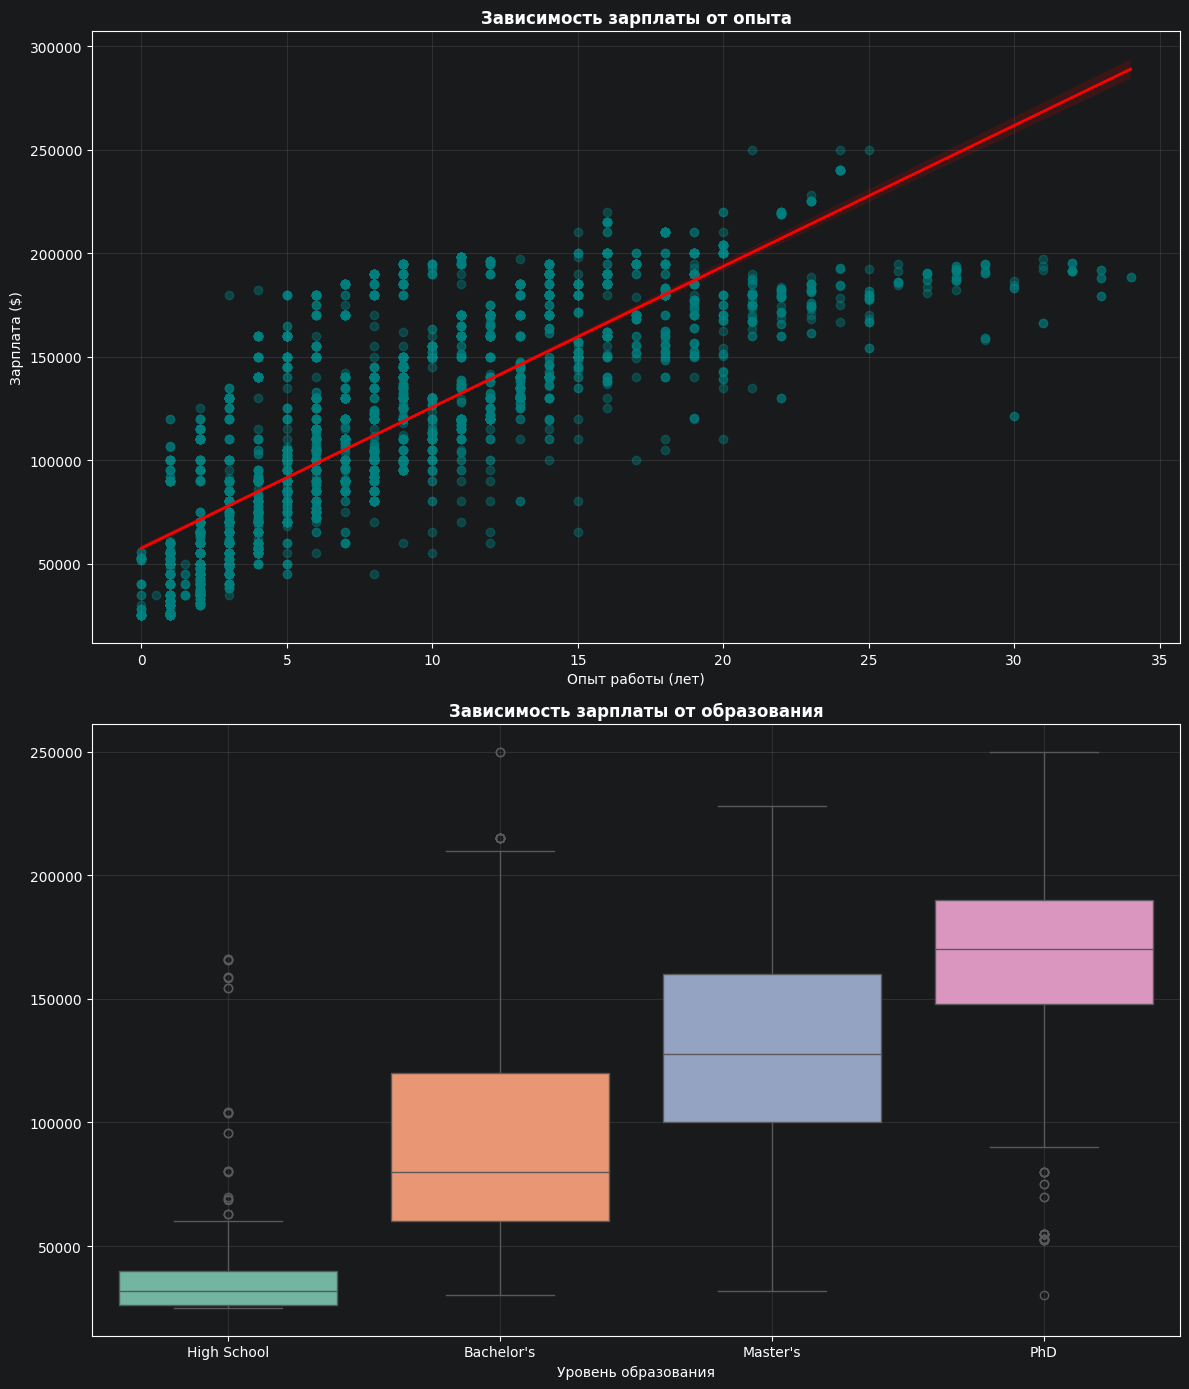

In [52]:
# Создаем сетку из 1 строки и 3 столбцов
fig, axes = plt.subplots(2, 1, figsize=(12, 14))

# --- ГИПОТЕЗА 1: Зарплата от Опыта и Образования ---

# 1.1. Зарплата и Опыт (Скаттерплот) для просмотра формы распределения
sns.regplot(data=sal_clean, x='Years of Experience', y='Salary', ax=axes[0],
            scatter_kws={'alpha':0.4, 'color': 'teal'}, line_kws={'color': 'red', 'linewidth': 2})
axes[0].set_title('Зависимость зарплаты от опыта', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Опыт работы (лет)')
axes[0].set_ylabel('Зарплата ($)')
axes[0].grid(True, alpha=0.2)

# 1.2. Зарплата и Образование (Боксплот)
edu_order = ['High School', "Bachelor's", "Master's", 'PhD']
actual_edu_order = [e for e in edu_order if e in sal_clean['Education Level'].unique()]

sns.boxplot(data=sal_clean, x='Education Level', y='Salary', order=actual_edu_order, ax=axes[1], palette='Set2')
axes[1].set_title('Зависимость зарплаты от образования', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Уровень образования')
axes[1].set_ylabel('')
axes[1].grid(True, alpha=0.2)


plt.tight_layout()
plt.show()

In [53]:
# Корреляция Пирсона
pearson_corr = sal_clean['Years of Experience'].corr(sal_clean['Salary'], method='pearson')
# Корреляция Спирмена
spearman_corr = sal_clean['Years of Experience'].corr(sal_clean['Salary'], method='spearman')

print(f"📊 Корреляция Пирсона (линейная): {pearson_corr:.2f}")
print(f"📈 Корреляция Спирмена (ранговая): {spearman_corr:.2f}")

📊 Корреляция Пирсона (линейная): 0.81
📈 Корреляция Спирмена (ранговая): 0.86


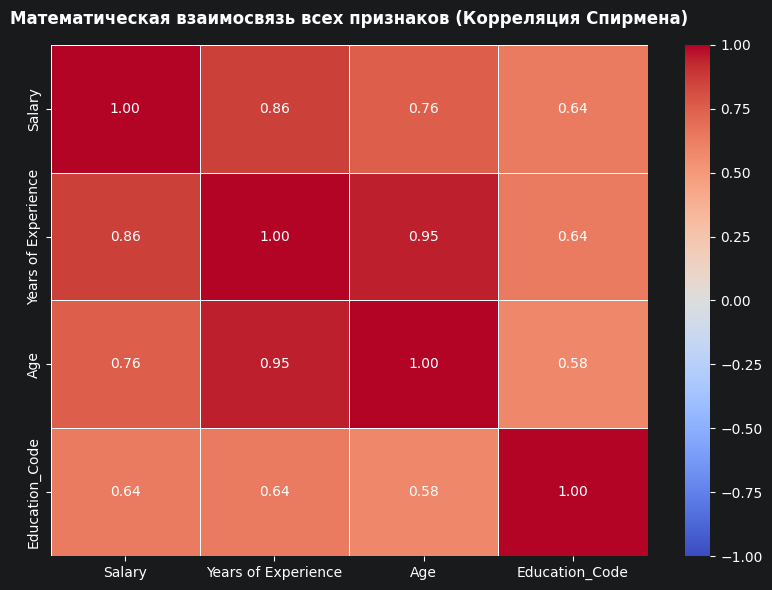

In [54]:
# Выбираем столбцы для матрицы
# 1. Шаг оцифровки (маппинга) — создаем колонку 'Education_Code'
edu_mapping = {'High School': 0, "Bachelor's": 1, "Master's": 2, 'PhD': 3}
sal_clean['Education_Code'] = sal_clean['Education Level'].map(edu_mapping)

# 2. Собираем список колонок (проверяй точное совпадение букв!)
matrix_cols = ['Salary', 'Years of Experience', 'Age', 'Education_Code']

# 3. Считаем корреляцию Спирмена
corr_matrix = sal_clean[matrix_cols].corr(method='spearman')

# 4. Рисуем красивую тепловую карту
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1, linewidths=0.5)
plt.title('Математическая взаимосвязь всех признаков (Корреляция Спирмена)', fontsize=12, fontweight='bold', pad=15)

plt.tight_layout()
plt.show()

##### ответ на гипотезу 1:
Анализируя график № 1 распределение зависимости зарплаты от опыта - до 15-20 лет идет будто линейная зависимость чем больше опыта тем больше оплата, но вот после этого порога происходит рассеивание и у нас нет очевидного роста

Анализируя график № 2 Boxplot зависимость зарплаты от уровня образования: Если посмотреть на медианы, то с каждым более продвинутым уровнем образования медианная зарплата выше.

Если смотреть тепловую карту, вообще одинаково зависят
- Поэтому прямо сказать, что например образование влияет сильнее, чем опыт работы на зарплату однозначно нельзя.

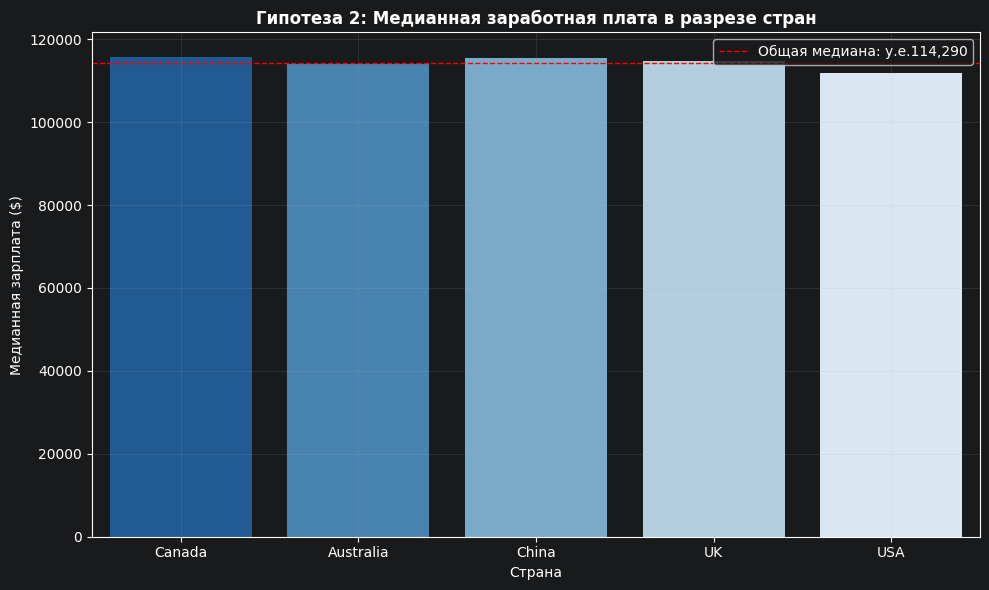

In [55]:
# --- ГИПОТЕЗА 2: Зарплата от Страны ---
plt.figure(figsize=(10, 6))

# 1. Вычисляем порядок стран по их медианной зарплате
country_order = sal_clean.groupby('Country')['Salary'].median().sort_values(ascending=False).index

# 2. Находим ОБЩУЮ медиану зарплаты по всей компании/датасету
global_median = sal_clean['Salary'].median()

# 3. Строим столбчатую диаграмму
sns.barplot(
    data=sal_clean,
    x='Country',
    y='Salary',
    order=country_order,
    palette='Blues_r',
    errorbar=None
)

# 4. Добавляем горизонтальную линию общей медианы
plt.axhline(
    y=global_median,
    color='red',
    linestyle='--',
    linewidth=1,
    label=f'Общая медиана: у.е.{global_median:,.0f}'
)

# Настраиваем отображение текста и легенды
plt.title('Гипотеза 2: Медианная заработная плата в разрезе стран', fontsize=12, fontweight='bold')
plt.xlabel('Страна', fontsize=10)
plt.ylabel('Медианная зарплата ($)', fontsize=10)
plt.grid(True, alpha=0.2)
plt.legend(loc='upper right')  # Показывает плашку с подписью красной линии

plt.tight_layout()
plt.show()

##### ответ на 2 гипотезу:
Существенных различий в медианной оплате труда - не заметно. на взягляд примерно +/- 1тыс.

- Существенного различия нет!

In [56]:
# Импорт библиотеки phik
!pip install phik
import phik
from phik import resources, report

Матрица корреляций φk

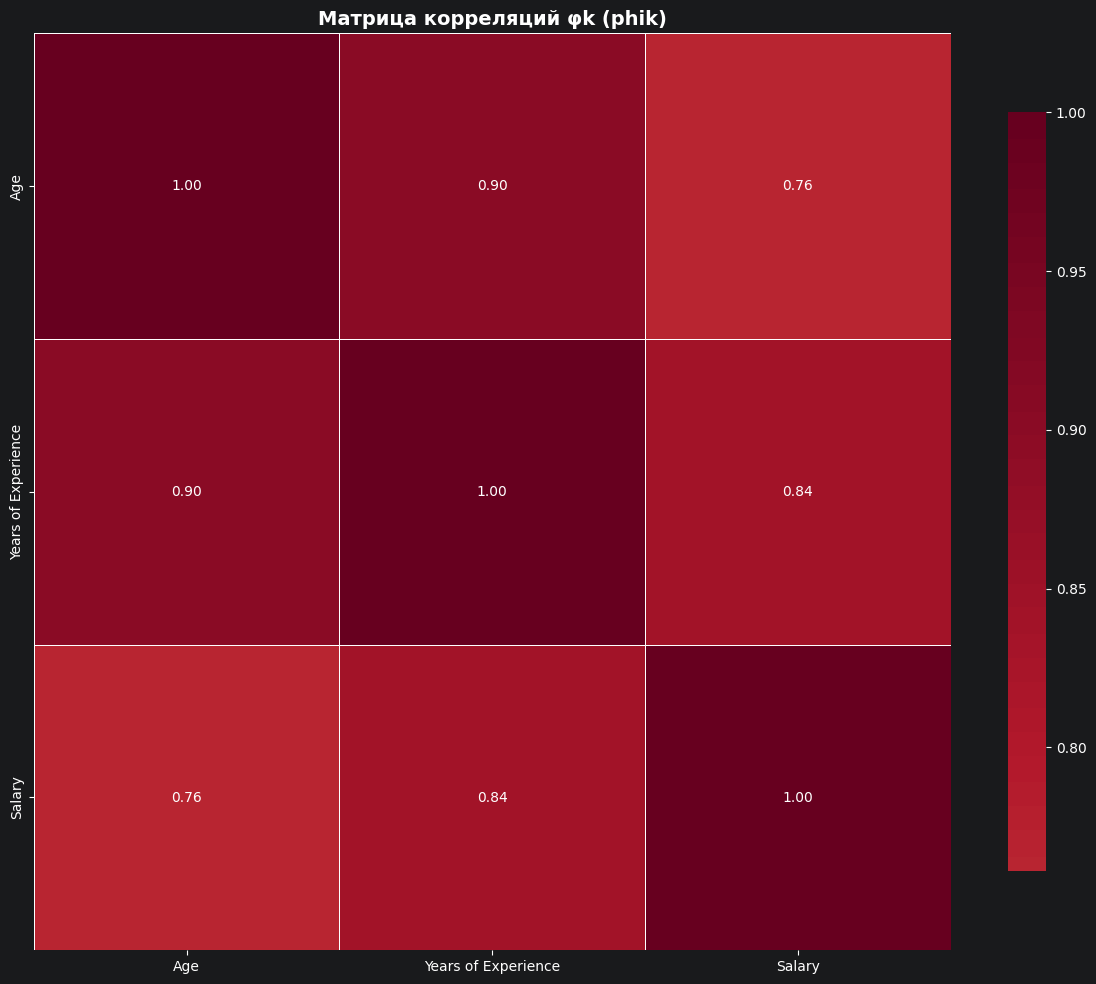

In [57]:
# Определяем интервальные (непрерывные) переменные
interval_cols = ['Salary', 'Years of Experience', 'Age']

# Расчёт матрицы phik с явным указанием интервальных переменных
phik_matrix = sal_optimized.drop(['Country', 'Gender', 'Job Title', 'Race', 'Education Level'],
                      axis=1).phik_matrix(interval_cols=interval_cols)

# Heatmap
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(phik_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Матрица корреляций φk (phik)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [58]:
# до оптимизации оригинальный датасет

profile = ProfileReport(
    sal,
    title="salary_dataset",
    explorative=True,
    correlations={
    "auto": {"calculate": False},
    "phi_k": {"calculate": True}
    }
)
profile

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 8/8 [00:00<00:00, 272.58it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [59]:
# после оптимизации

profile = ProfileReport(
    sal_optimized,
    title="salary_dataset",
    explorative=True,
    correlations={
    "auto": {"calculate": False},
    "phi_k": {"calculate": True}
    }
)
profile

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 8/8 [00:00<00:00, 553.63it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [60]:
# Сохранение в HTML
profile.to_file("spotify_eda_report.html")
# если нужно будет

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

тестим графику